In [27]:
import pandas as pd
import matplotlib.pyplot as plt   
import numpy  as np
import seaborn as sns

In [19]:
df = pd.read_csv('C:\\Users\\jyoth\\OneDrive\\Documents\\For Practice\\train.csv')
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [9]:
# Overview of dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Check for missing values
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
# Unique values in each column
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [23]:
# Frequency count of categorical columns
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts(), "\n")

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64 

Sex
male      577
female    314
Name: count, dtype: int64 

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64 

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148      

In [ ]:
## Observations:
info() shows data types and null values.

describe() reveals ranges, means, std, and percentiles for numerical columns.

value_counts() helps spot imbalances in categorical features.
    
Missing values detected:

Age: 177 missing values.

Cabin: 687 missing values (most of the column).

Embarked: 2 missing values.




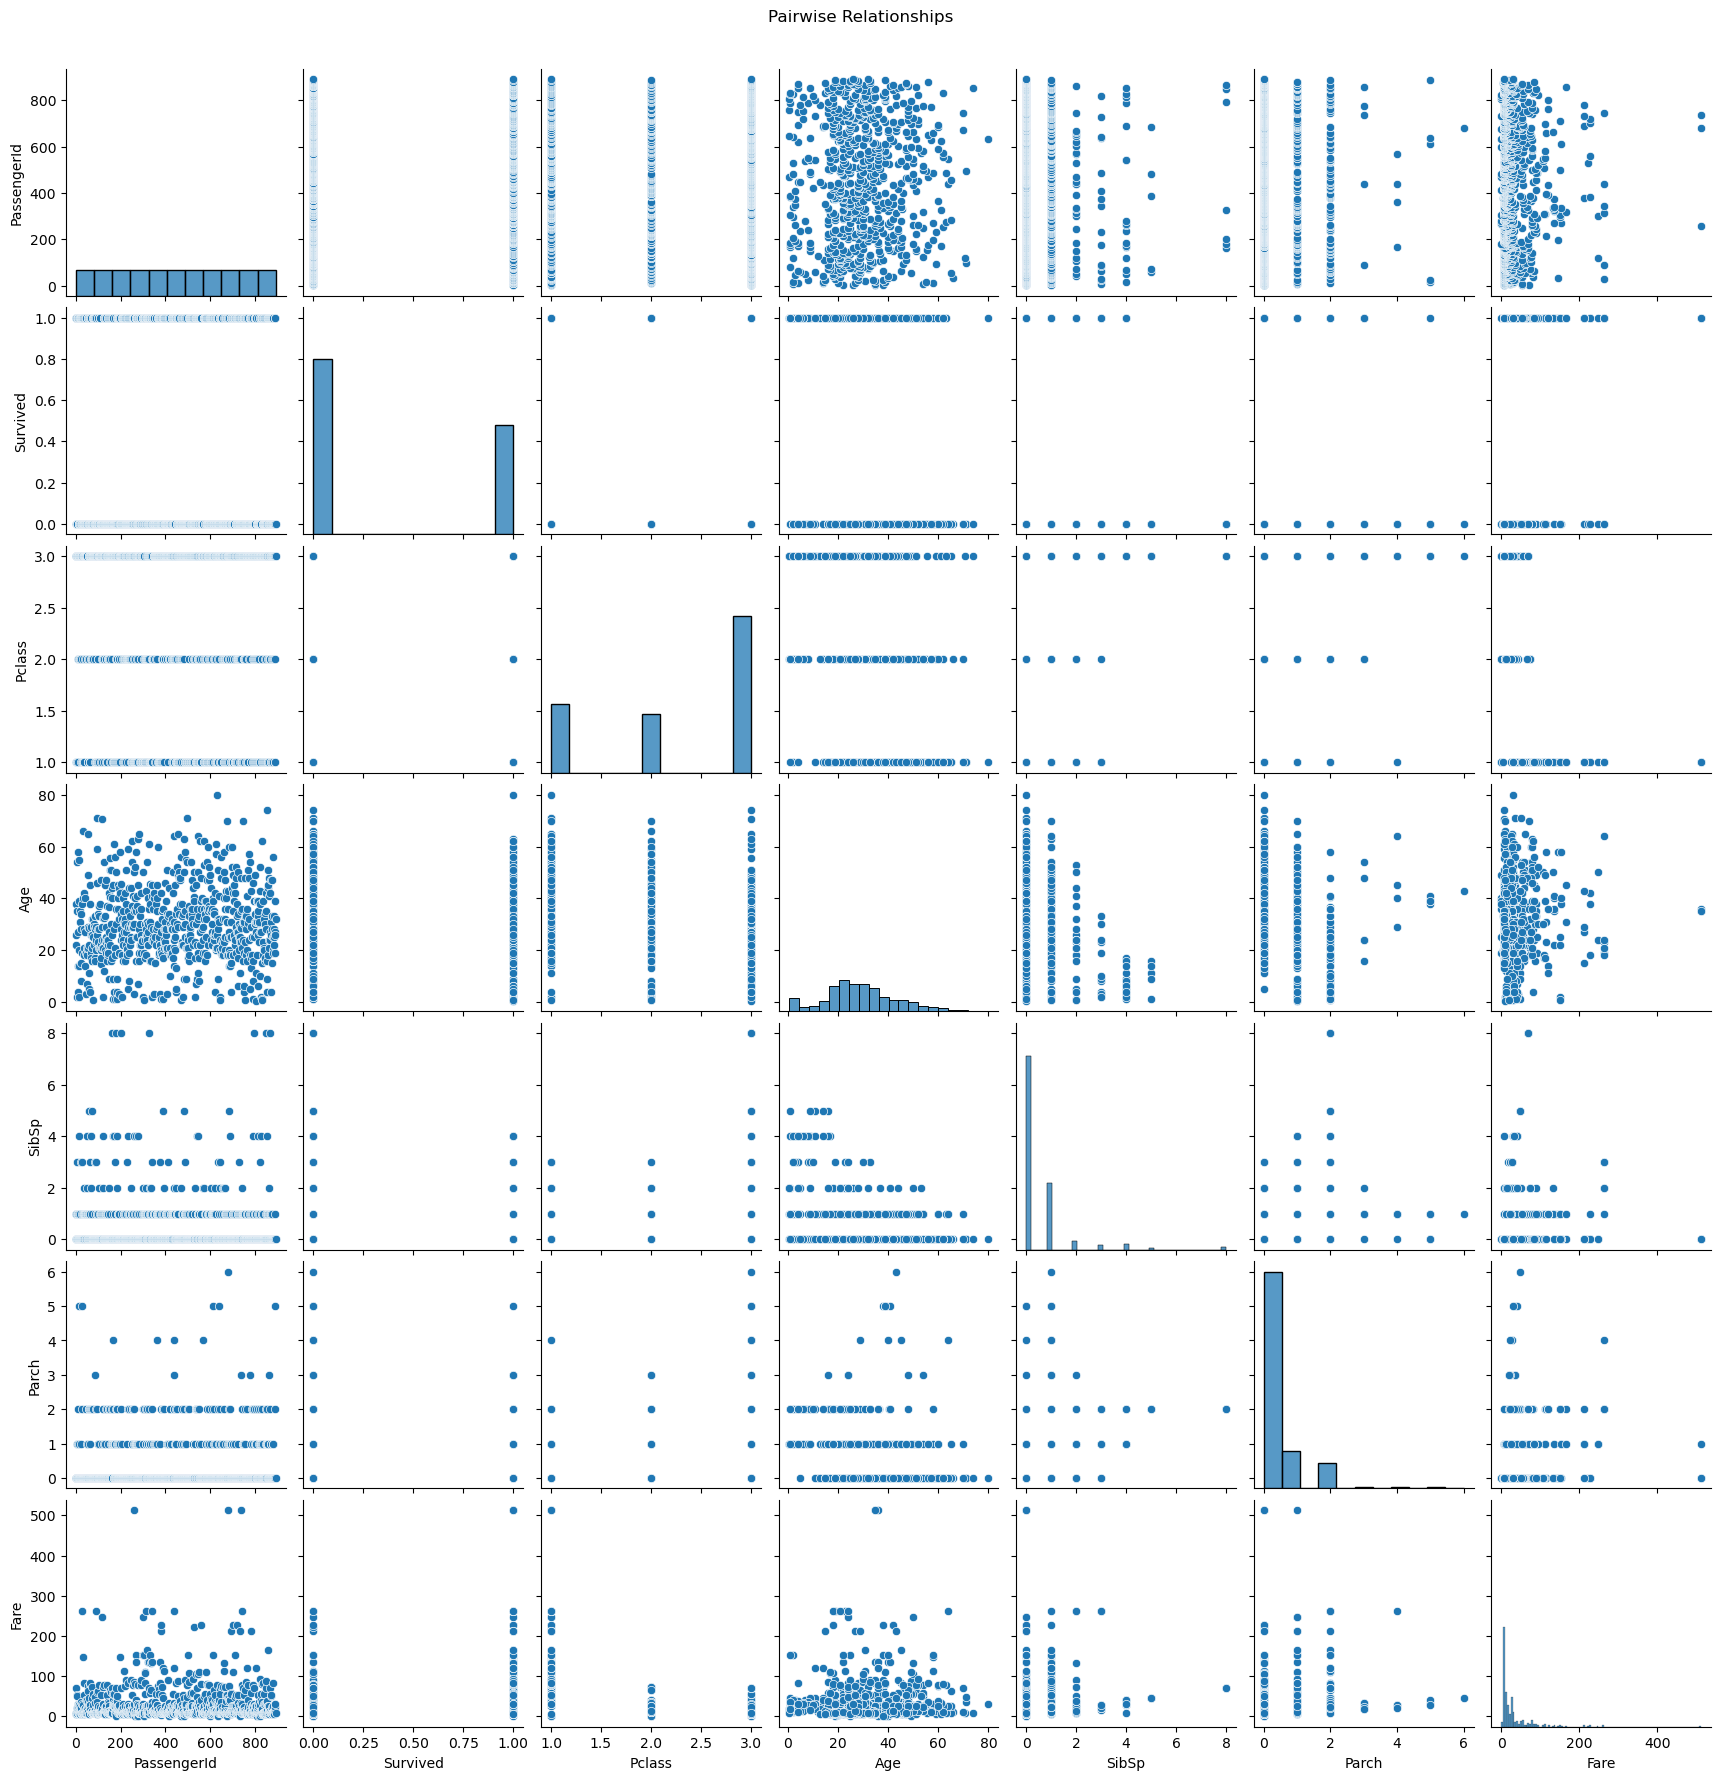

In [29]:
# Pairwise relationships
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

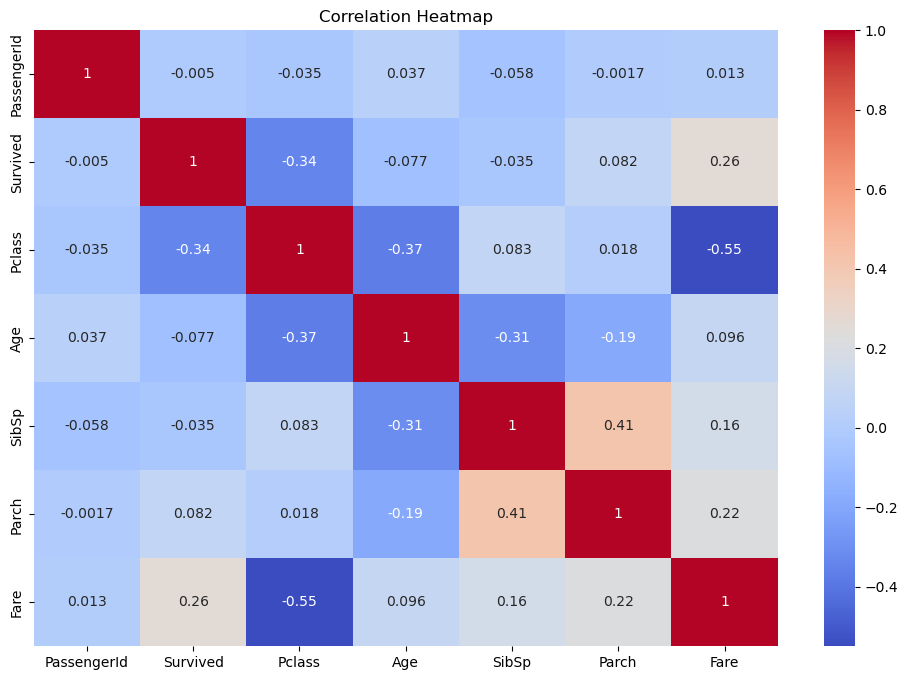

In [33]:
# Correlation heatmap for numeric columns only
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
 ** Observations:
Use pairplot to see linear or clustered relationships.

heatmap helps identify strongly correlated variables (positively or negatively).

Mention any multicollinearity or potential features for prediction.

** Age vs Fare (to spot trend by ticket price & age)

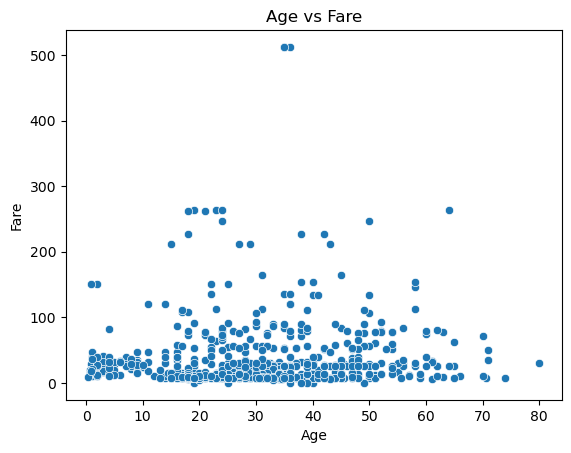

In [37]:
sns.scatterplot(data=df, x='Age', y='Fare')
plt.title('Age vs Fare')
plt.show()

In [ ]:
** SibSp vs Parch (to explore family size relationship)

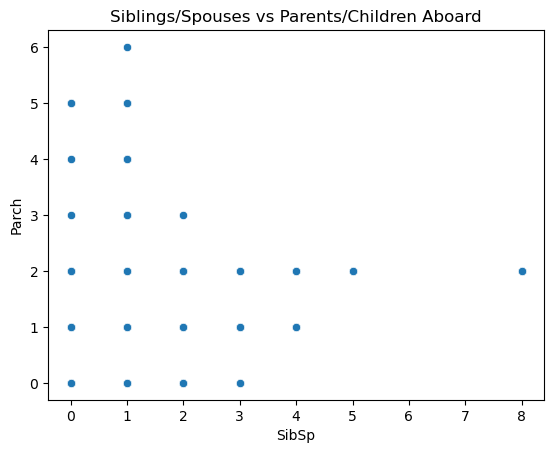

In [39]:
sns.scatterplot(data=df, x='SibSp', y='Parch')
plt.title('Siblings/Spouses vs Parents/Children Aboard')
plt.show()

In [ ]:
** Observations:
Most passengers (bottom-left cluster) traveled alone (0 siblings/spouses, 0 parents/children).

Some clusters show:

SibSp = 1 and Parch = 0–2: Likely small family or couples.

SibSp = 1–2 and Parch = 1–3: Medium-sized families.

A few outliers:

One case with 5 siblings/spouses and 6 parents/children → Large family group.

There is a positive trend — passengers with siblings/spouses often had parents/children too, suggesting family-based travel patterns.



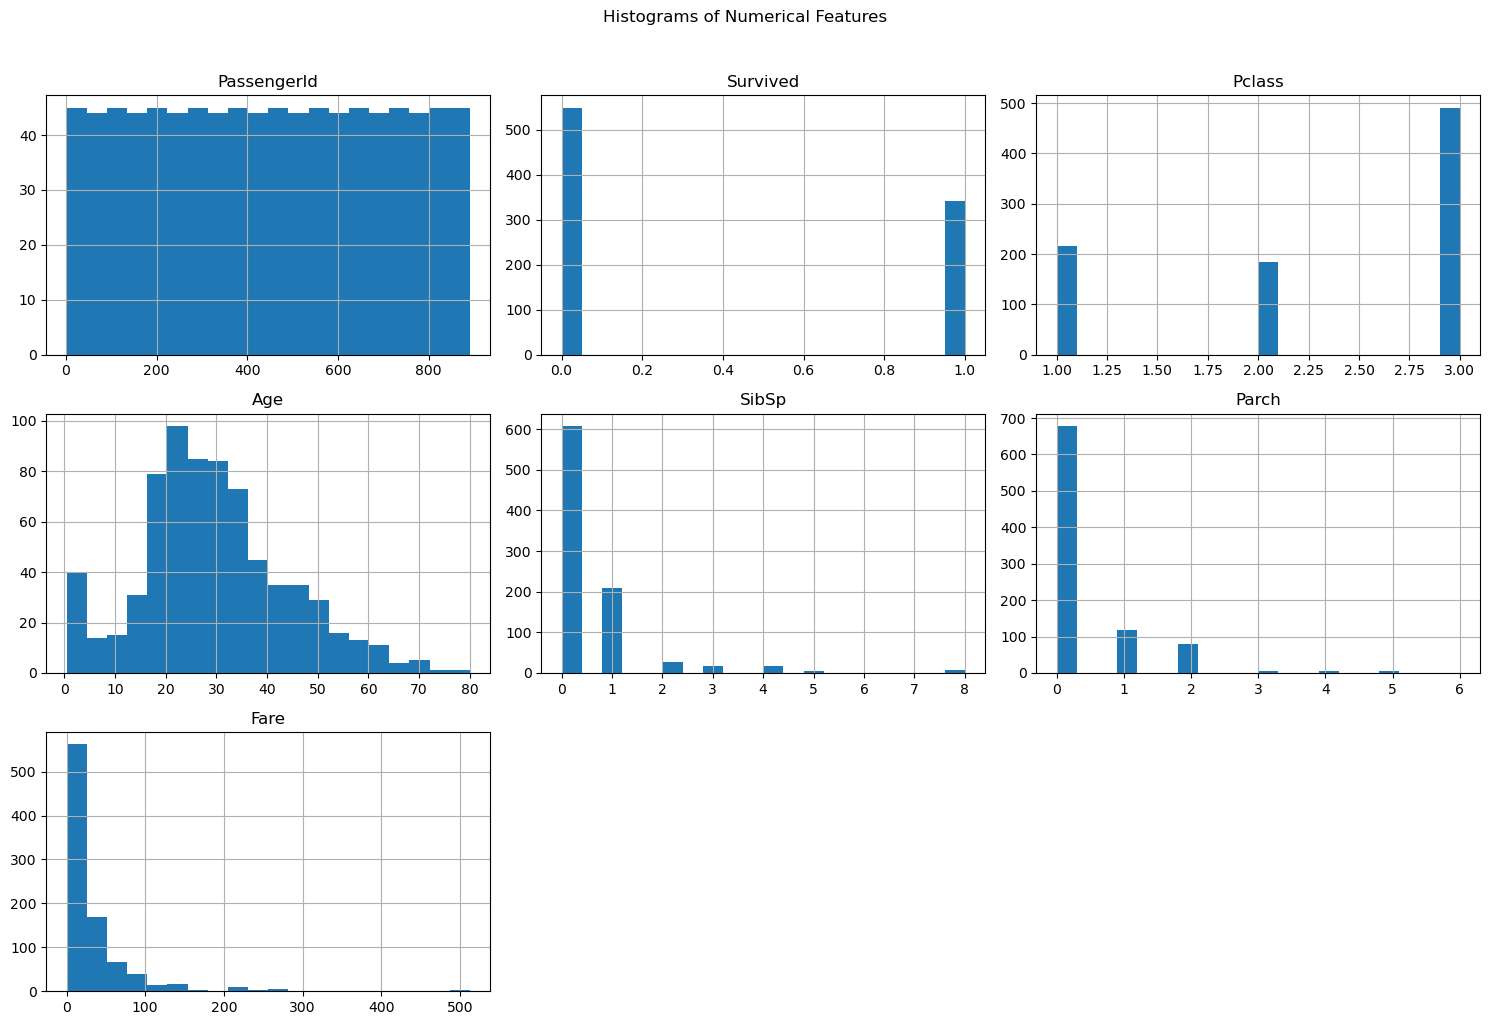

In [43]:
# Histograms
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()


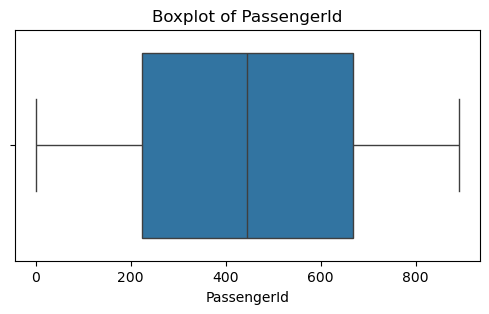

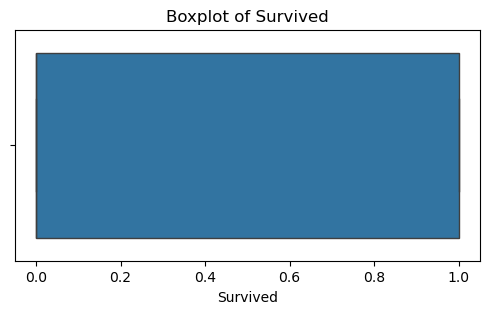

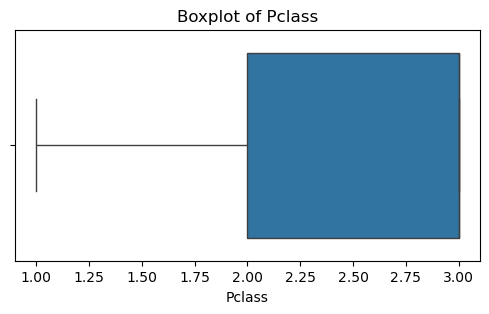

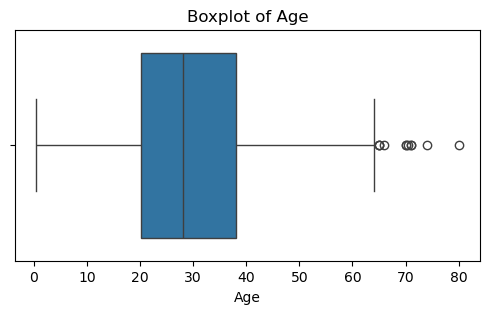

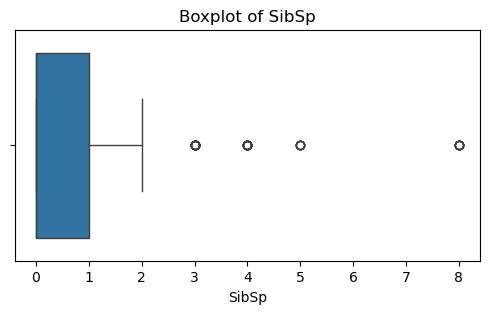

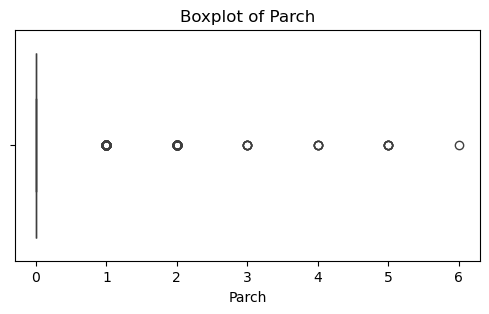

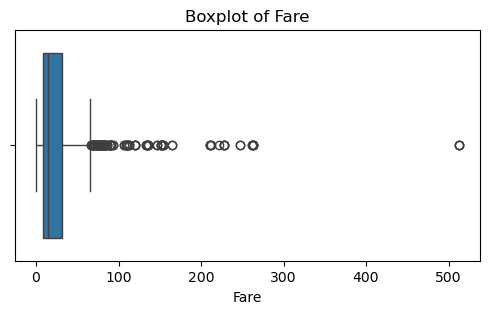

In [45]:
## Boxplots to detect outliers
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
** Observations:
 ## Histograms show skewness, distribution type (normal, bimodal, etc.)

## Boxplots help detect outliers.

## Mention if scaling/transformation is needed due to skewness or outliers.

